In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# size of house (in 1000 sq ft)
X = np.array([1, 2, 3, 4, 5])

# price (in $1000)
y = np.array([2, 4, 5, 4, 5])

m = len(X)

print("Number of training examples:", m)

Number of training examples: 5


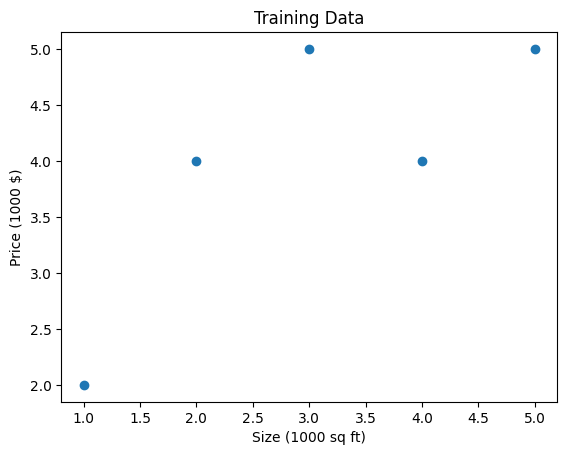

In [3]:
plt.scatter(X, y)
plt.xlabel("Size (1000 sq ft)")
plt.ylabel("Price (1000 $)")
plt.title("Training Data")
plt.show()

In [4]:
def compute_model_output(X, w, b):
    return w * X + b

In [5]:
def compute_cost(X, y, w, b):
    m = len(X)
    cost = 0

    for i in range(m):
        f_wb = w * X[i] + b
        cost += (f_wb - y[i])**2

    cost = cost / (2 * m)
    return cost

In [6]:
def compute_gradient(X, y, w, b):
    m = len(X)

    dj_dw = 0
    dj_db = 0

    for i in range(m):
        error = (w * X[i] + b) - y[i]
        dj_dw += error * X[i]
        dj_db += error

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [7]:
def gradient_descent(X, y, w, b, alpha, iterations):

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.4f}")

    return w, b, cost_history

In [8]:
w_init = 0
b_init = 0

alpha = 0.01
iterations = 1000

w, b, cost_history = gradient_descent(X, y, w_init, b_init, alpha, iterations)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Iteration 0: Cost 6.8101
Iteration 100: Cost 0.4707
Iteration 200: Cost 0.4045
Iteration 300: Cost 0.3573
Iteration 400: Cost 0.3236
Iteration 500: Cost 0.2996
Iteration 600: Cost 0.2825
Iteration 700: Cost 0.2703
Iteration 800: Cost 0.2616
Iteration 900: Cost 0.2554

Final parameters:
w = 0.6963550004885218
b = 1.8521278749603411


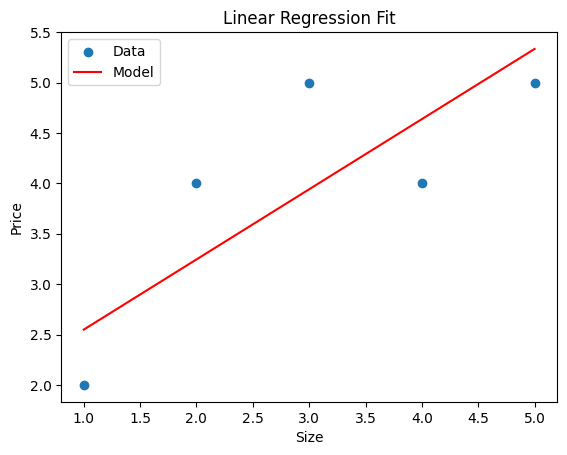

In [9]:
predictions = compute_model_output(X, w, b)

plt.scatter(X, y, label="Data")
plt.plot(X, predictions, color='red', label="Model")
plt.xlabel("Size")
plt.ylabel("Price")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

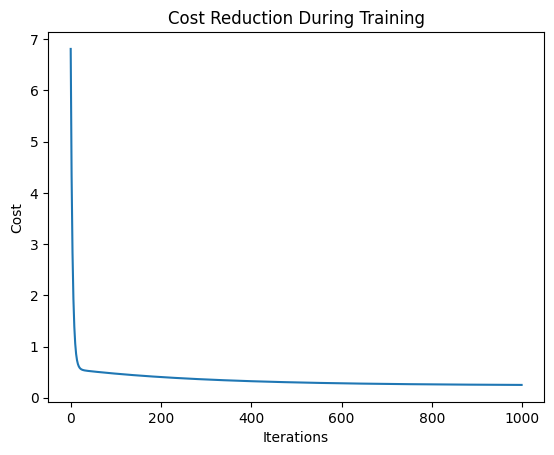

In [10]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction During Training")
plt.show()

In [11]:
x_test = 6
prediction = w * x_test + b

print(f"\nPredicted price for size {x_test}: {prediction:.2f}")


Predicted price for size 6: 6.03


In [12]:
def compute_cost_vectorized(X, y, w, b):
    m = len(X)
    predictions = w * X + b
    return np.sum((predictions - y)**2) / (2*m)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Features: [size, bedrooms, age]
X = np.array([
    [850, 2, 12],
    [900, 3, 8],
    [1200, 3, 5],
    [1500, 4, 2],
    [1700, 4, 1],
    [2000, 5, 1]
])

# Prices
y = np.array([200, 250, 300, 400, 450, 500])

m, n = X.shape

print("Examples:", m)
print("Features:", n)

Examples: 6
Features: 3


In [15]:
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_norm = (X - mu) / sigma

In [16]:
def compute_model_output(X, w, b):
    return np.dot(X, w) + b

In [17]:
def compute_cost(X, y, w, b):
    m = len(X)
    predictions = np.dot(X, w) + b
    return np.sum((predictions - y)**2) / (2*m)

In [18]:
def compute_gradient(X, y, w, b):
    m = len(X)

    predictions = np.dot(X, w) + b
    error = predictions - y

    dj_dw = np.dot(X.T, error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [19]:
def gradient_descent(X, y, w, b, alpha, iterations):

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.2f}")

    return w, b, cost_history

In [20]:
w_init = np.zeros(n)
b_init = 0

alpha = 0.01
iterations = 1000

w, b, cost_history = gradient_descent(X_norm, y, w_init, b_init, alpha, iterations)

print("\nFinal parameters:")
print("w =", w)
print("b =", b)

Iteration 0: Cost 65540.23
Iteration 100: Cost 8134.90
Iteration 200: Cost 1148.15
Iteration 300: Cost 210.50
Iteration 400: Cost 81.63
Iteration 500: Cost 61.51
Iteration 600: Cost 56.31
Iteration 700: Cost 53.40
Iteration 800: Cost 51.07
Iteration 900: Cost 49.04

Final parameters:
w = [ 51.47811451  29.94441374 -28.38534181]
b = 349.9848900634062


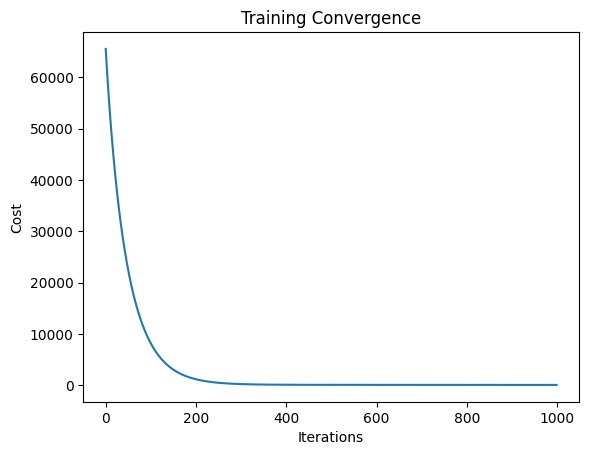

In [21]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Training Convergence")
plt.show()

In [22]:
# New house: [size, bedrooms, age]
x_new = np.array([1600, 3, 2])

# normalize
x_new_norm = (x_new - mu) / sigma

prediction = np.dot(x_new_norm, w) + b

print(f"\nPredicted price: {prediction:.2f}")


Predicted price: 384.01


In [23]:
np.random.seed(0)

m = 100

temp = np.random.uniform(15, 35, m)
humidity = np.random.uniform(30, 90, m)
wind = np.random.uniform(0, 10, m)
occupancy = np.random.randint(1, 10, m)
time = np.random.uniform(0, 24, m)

# true relationship (nonlinear)
y = (
    2*temp +
    0.5*humidity -
    1.5*wind +
    5*occupancy +
    10*np.sin(time/24 * 2*np.pi) +
    np.random.normal(0, 5, m)
)

In [24]:
def create_features(temp, humidity, wind, occupancy, time):

    return np.column_stack([
        temp,
        humidity,
        wind,
        occupancy,
        np.sin(time/24 * 2*np.pi),   # cyclic time
        temp**2,                     # nonlinear
        humidity * temp              # interaction
    ])

In [25]:
X = create_features(temp, humidity, wind, occupancy, time)

In [26]:
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

X_norm = (X - mu) / sigma

In [27]:
def compute_cost(X, y, w, b, lambda_):
    m = len(X)
    pred = np.dot(X, w) + b

    cost = np.sum((pred - y)**2) / (2*m)
    reg = (lambda_ / (2*m)) * np.sum(w**2)

    return cost + reg

In [28]:
def compute_gradient(X, y, w, b, lambda_):
    m = len(X)

    pred = np.dot(X, w) + b
    error = pred - y

    dj_dw = np.dot(X.T, error) / m + (lambda_/m)*w
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

In [29]:
def gradient_descent(X, y, w, b, alpha, iterations, lambda_):

    cost_history = []

    for i in range(iterations):

        dj_dw, dj_db = compute_gradient(X, y, w, b, lambda_)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X, y, w, b, lambda_)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:.2f}")

    return w, b, cost_history

In [30]:
n = X_norm.shape[1]

w = np.zeros(n)
b = 0

alpha = 0.01
iterations = 1000
lambda_ = 0.1

w, b, cost_history = gradient_descent(X_norm, y, w, b, alpha, iterations, lambda_)

Iteration 0: Cost 4810.05
Iteration 100: Cost 651.66
Iteration 200: Cost 102.27
Iteration 300: Cost 28.65
Iteration 400: Cost 18.75
Iteration 500: Cost 17.40
Iteration 600: Cost 17.20
Iteration 700: Cost 17.15
Iteration 800: Cost 17.12
Iteration 900: Cost 17.10
